# BRFSS 2015 Diabetes Health Indicators — Predictive Models

**Authors:** Wolfgang Klein, Sydney Bailey, Harvey Luna, Nashita Kandaker
**Data:** `diabetes_012_health_indicators_BRFSS2015.csv`, target collapsed to binary
(prediabetes and diabetes both coded 1)

## Intro

In [Lab 1](https://lone-wolfgang.github.io/brfss2015-diabetes-eda/#Lab1/WolfgangKlein)
we explored a dataset that links health, demographics, and income to a diabetes
diagnosis. See Lab 1 for the full data review.

The goal here is to build two predictive models.

## Models

We train two model families: logistic regression and support vector machines (SVM).

**Logistic regression** is fast to fit. If its assumptions hold, the coefficients
are easy to interpret. Non-linear effects can be added with squared terms and
interactions.

**SVM** is a non-parametric model. It learns a boundary between the classes. The
main choice is the kernel: linear (fast), polynomial (curved boundaries), or RBF
(most flexible, slowest).

Lab 1 supported logistic regression, and a first model reached an AUC of 0.814.
We expect logistic regression to perform about as well as the SVMs. RBF is slow,
so it will first be tried on a subset.

Section 4 screens the SVM kernels. Only the linear kernel is carried forward.

## Metrics

The model flags people at risk of diabetes so they can be referred for screening.
Missing a case is costly, and so is an unneeded referral.

- **Recall**: share of true cases we flag.
- **Precision**: share of flags that are true cases.

Recall matters more, so models are compared on **F2**, which weights recall above
precision.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             fbeta_score, precision_score, recall_score, confusion_matrix)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", "#b5442e", "#5c1d13"], as_cmap=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.7,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": PALETTE["ink"], "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"], "ytick.color": PALETTE["ink"],
    "legend.frameon": False, "figure.facecolor": "white",
})

SEED = 0
print("pandas", pd.__version__, "| numpy", np.__version__, "| statsmodels", sm.__version__)

pandas 3.0.2 | numpy 2.4.4 | statsmodels 0.15.0


In [2]:
import os

PATH = "../data/diabetes_012_health_indicators_BRFSS2015.csv"
assert os.path.exists(PATH), f"Dataset not found at {PATH}. See README for setup."

raw = pd.read_csv(PATH)
raw["Diabetes_binary"] = (raw["Diabetes_012"] > 0).astype(int)
raw = raw.drop(columns="Diabetes_012")

TARGET = "Diabetes_binary"
print(f"shape   : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"target  : {TARGET}, prevalence {100*raw[TARGET].mean():.2f}%")

shape   : 253,680 rows x 22 columns
target  : Diabetes_binary, prevalence 15.76%


## 1. Feature Considerations

Three changes, all from Lab 1:

- **Drop `CholCheck`.** Lab 1 §11 showed it tracks access to a doctor, not disease.
- **Winsorize BMI at 70.** Values above 70 are a data artifact.
- **Add squared terms for Age and Income.** Both curves bend. Each is centered
  before squaring.

In [3]:
df = raw.drop(columns="CholCheck").copy()
df["BMI"] = np.minimum(df["BMI"], 70)

for col in ["Age", "Income"]:
    df[col] = df[col] - df[col].mean()
    df[f"{col}_sq"] = df[col] ** 2

FEATURES = [c for c in df.columns if c != TARGET]
print(f"{len(FEATURES)} features:", ", ".join(FEATURES))

22 features: HighBP, HighChol, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, Age_sq, Income_sq


## 2. Splits

The data is split 70 / 15 / 15, stratified on the target.

- **train (70%)**: fits the model. For the SVMs it will also be used for tuning with
  5-fold CV.
- **validation (15%)**: picks the decision threshold.
- **test (15%)**: final, unbiased score at the chosen threshold.

In [4]:
X, y = df[FEATURES], df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

display(pd.DataFrame({
    "rows":         [len(y_train), len(y_val), len(y_test)],
    "share %":      [100*len(y_train)/len(y), 100*len(y_val)/len(y), 100*len(y_test)/len(y)],
    "prevalence %": [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()],
}, index=["train", "validation", "test"]).round(2))

,rows,share %,prevalence %
train,177576,70.0000,15.7600
validation,38052,15.0000,15.7600
test,38052,15.0000,15.7600


## 3. Logistic Regression

The model is fit on the training set. The table shows each coefficient, its odds
ratio, and a 95% confidence interval.

In [5]:
logit = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)

ci = logit.conf_int()
params = pd.DataFrame({
    "coef":       logit.params,
    "ci_low":     ci[0],
    "ci_high":    ci[1],
    "odds_ratio": np.exp(logit.params),
    "or_low":     np.exp(ci[0]),
    "or_high":    np.exp(ci[1]),
    "p_value":    logit.pvalues,
})
display(params.round(4))
print(f"McFadden pseudo-R2: {logit.prsquared:.4f}")

,coef,ci_low,ci_high,odds_ratio,or_low,or_high,p_value
const,-5.5032,-5.6442,-5.3623,0.0041,0.0035,0.0047,0.0000
HighBP,0.6953,0.6630,0.7277,2.0044,1.9405,2.0704,0.0000
HighChol,0.5714,0.5412,0.6016,1.7708,1.7180,1.8251,0.0000
BMI,0.0647,0.0626,0.0669,1.0669,1.0646,1.0692,0.0000
Smoker,-0.0295,-0.0591,0.0001,0.9709,0.9426,1.0001,0.0504
Stroke,0.1153,0.0577,0.1729,1.1222,1.0593,1.1887,0.0001
HeartDiseaseorAttack,0.2175,0.1767,0.2584,1.2430,1.1933,1.2948,0.0000
PhysActivity,-0.0472,-0.0796,-0.0147,0.9539,0.9235,0.9854,0.0044
Fruits,-0.0446,-0.0752,-0.0139,0.9564,0.9275,0.9862,0.0044
Veggies,-0.0463,-0.0819,-0.0106,0.9548,0.9213,0.9895,0.0110


McFadden pseudo-R2: 0.2067


Odds ratios above 1 raise the risk, and below 1 lower it. For binary features, the
odds ratio compares a 1 to a 0. For the others, it is the change per one unit.

## 4. SVM Kernel Screen

Is any SVM kernel better than logistic regression here? This screen decides which
kernels go into the overnight search.

- Fit on 50,000 rows sampled from `train`. Score AUC on the rest of `train`.
- Every model uses `class_weight="balanced"`. Without it, the non-linear SVMs rank
  poorly.
- A non-linear kernel is kept only if it beats logistic regression by at least
  **0.005 AUC**. The linear SVM is cheap, so it is always kept.

The screen takes about 30 minutes. Progress prints as each trial finishes. The slow
trials run first, so the first lines take a few minutes to appear. Each finished
trial is saved to `cache/kernel_screen.jsonl`. If the run is stopped, running the
cell again skips the trials already saved.

In [6]:
import json, time
from pathlib import Path
from joblib import Parallel, delayed
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression

SCREEN_ROWS = 50_000
X_fit, X_ev, y_fit, y_ev = train_test_split(
    X_train, y_train, train_size=SCREEN_ROWS, stratify=y_train, random_state=SEED)

TRIALS  = [dict(kernel="logistic")]
TRIALS += [dict(kernel="linear", C=C) for C in [0.01, 0.1, 1, 10]]
TRIALS += [dict(kernel="poly", degree=2, C=C, coef0=c0) for C in [0.1, 1, 10] for c0 in [0.5, 1, 2]]
TRIALS += [dict(kernel="poly", degree=3, C=C, coef0=c0) for C in [0.1, 1] for c0 in [1, 2]]
TRIALS += [dict(kernel="rbf", C=C, gamma=g) for C in [0.1, 1, 10] for g in [0.003, 0.01, 0.03]]
TRIALS += [dict(kernel="sigmoid", C=C, gamma=g, coef0=0) for C in [0.1, 1, 10] for g in [0.0003, 0.001, 0.003]]

# slowest first: large C, then the costlier kernels
COST = {"rbf": 3, "poly": 2, "sigmoid": 1, "linear": 0, "logistic": 0}
TRIALS.sort(key=lambda t: (-t.get("C", 0), -COST[t["kernel"]]))


def build(t):
    p = {k: v for k, v in t.items() if k != "kernel"}
    if t["kernel"] == "logistic":
        est = LogisticRegression(max_iter=2000, class_weight="balanced")
    elif t["kernel"] == "linear":
        est = LinearSVC(class_weight="balanced", **p)
    else:
        est = SVC(kernel=t["kernel"], class_weight="balanced", cache_size=2000, **p)
    return make_pipeline(StandardScaler(), est)


def run_trial(t):
    model = build(t)
    t0 = time.perf_counter(); model.fit(X_fit, y_fit); fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); s = model.decision_function(X_ev); score_s = time.perf_counter() - t0
    est = model[-1]
    return dict(params=t, auc=roc_auc_score(y_ev, s), fit_s=fit_s, score_s=score_s,
                n_support=int(est.n_support_.sum()) if hasattr(est, "n_support_") else None)


def label(t):
    return " ".join([t["kernel"]] + [f"{k}={v}" for k, v in t.items() if k != "kernel"])


LOG = Path("cache/kernel_screen.jsonl")
LOG.parent.mkdir(exist_ok=True)
key  = lambda t: json.dumps(t, sort_keys=True)
done = {key(json.loads(line)["params"]) for line in LOG.read_text().splitlines()} if LOG.exists() else set()
todo = [t for t in TRIALS if key(t) not in done]
print(f"{len(TRIALS)} trials: {len(done)} already saved, {len(todo)} to run "
      f"(fit on {len(y_fit):,} rows, score on {len(y_ev):,})", flush=True)

start = time.perf_counter()
jobs  = Parallel(n_jobs=12, return_as="generator_unordered")(delayed(run_trial)(t) for t in todo)
for i, r in enumerate(jobs, 1):
    with LOG.open("a") as f:
        f.write(json.dumps(r) + "\n")
    print(f"[{i:2d}/{len(todo)}] {(time.perf_counter() - start) / 60:5.1f} min | "
          f"{label(r['params']):<34} AUC {r['auc']:.4f} | "
          f"fit {r['fit_s']:6.1f}s  score {r['score_s']:6.1f}s", flush=True)
print(f"finished in {(time.perf_counter() - start) / 60:.1f} min")


36 trials: 0 already saved, 36 to run (fit on 50,000 rows, score on 127,576)
[ 1/36]   0.0 min | linear C=10                        AUC 0.8163 | fit    0.1s  score    0.0s
[ 2/36]   1.6 min | sigmoid C=10 gamma=0.001 coef0=0   AUC 0.8158 | fit   49.8s  score   46.3s
[ 3/36]   1.7 min | sigmoid C=10 gamma=0.003 coef0=0   AUC 0.8116 | fit   50.4s  score   50.9s
[ 4/36]   1.8 min | sigmoid C=10 gamma=0.0003 coef0=0  AUC 0.8158 | fit   53.5s  score   51.8s
[ 5/36]   2.1 min | poly degree=2 C=10 coef0=0.5       AUC 0.8169 | fit   81.0s  score   44.7s
[ 6/36]   2.2 min | poly degree=2 C=10 coef0=1         AUC 0.8169 | fit   88.9s  score   44.4s
[ 7/36]   2.6 min | poly degree=2 C=10 coef0=2         AUC 0.8169 | fit  108.0s  score   44.0s
[ 8/36]   2.9 min | poly degree=2 C=1 coef0=0.5        AUC 0.8170 | fit   34.0s  score   43.6s
[ 9/36]   3.1 min | poly degree=2 C=1 coef0=1          AUC 0.8170 | fit   41.6s  score   43.0s
[10/36]   3.2 min | rbf C=1 gamma=0.03                 AUC 0.8079 | 

All trials, sorted by AUC.

In [7]:
rows = [json.loads(line) for line in LOG.read_text().splitlines()]
screen = pd.DataFrame([{**r["params"], "AUC": r["auc"], "fit s": r["fit_s"],
                        "score s": r["score_s"], "support vectors": r["n_support"]} for r in rows])
screen = screen[["kernel", "degree", "C", "gamma", "coef0",
                 "AUC", "fit s", "score s", "support vectors"]]
screen = screen.sort_values("AUC", ascending=False).reset_index(drop=True)
PARAM_FMT = {c: (lambda v: "" if pd.isna(v) else f"{v:g}")
             for c in ["degree", "C", "gamma", "coef0", "support vectors"]}
display(screen.style.format({**PARAM_FMT, "AUC": "{:.4f}", "fit s": "{:.1f}", "score s": "{:.1f}"})
        .hide(axis="index"))


kernel,degree,C,gamma,coef0,AUC,fit s,score s,support vectors
rbf,,1,0.003,,0.8189,56.9,142.4,29706
rbf,,0.1,0.01,,0.8183,59.0,113.7,30031
rbf,,10,0.003,,0.8178,53.7,137.7,28967
poly,2,0.1,,2,0.8176,45.3,44.0,28972
poly,2,0.1,,1,0.8175,47.9,44.3,29023
poly,2,0.1,,0.5,0.8174,48.3,44.7,29109
rbf,,1,0.01,,0.8173,55.3,137.4,29012
poly,2,1,,1,0.8170,41.6,43.0,28738
poly,2,1,,2,0.8170,43.6,42.9,28738
poly,2,1,,0.5,0.8170,34.0,43.6,28754


Best trial per kernel, compared with logistic regression.

In [8]:
KEEP_GAP = 0.005
lr_auc = screen.loc[screen.kernel == "logistic", "AUC"].iloc[0]

best = screen.loc[screen.groupby("kernel").AUC.idxmax()].sort_values("AUC", ascending=False)
best["gap vs logistic"] = best.AUC - lr_auc
# linear is cheap, so it stays in the overnight search regardless; the rule applies to the others
best["decision"] = np.select(
    [best.kernel == "logistic", best.kernel == "linear", best["gap vs logistic"] >= KEEP_GAP],
    ["baseline", "keep (cheap)", "keep"], "drop")
display(best[["kernel", "degree", "C", "gamma", "coef0", "AUC", "gap vs logistic", "decision"]]
        .style.format({**PARAM_FMT, "AUC": "{:.4f}", "gap vs logistic": "{:+.4f}"}, subset=None)
        .hide(axis="index"))


kernel,degree,C,gamma,coef0,AUC,gap vs logistic,decision
rbf,,1,0.003,,0.8189,+0.0022,drop
poly,2,0.1,,2,0.8176,+0.0009,drop
logistic,,,,,0.8167,+0.0000,baseline
linear,,10,,,0.8163,-0.0004,keep (cheap)
sigmoid,,10,0.001,0,0.8158,-0.0009,drop


### Linear SVM tuning

The screen showed that the polynomial and RBF kernels do not beat logistic
regression by enough to justify their training time, so the SVM is **linear**.

Its hyperparameters are tuned on the full training set with stratified **5-fold CV**.
Folds are scored on AUC, which does not depend on a threshold. The threshold is picked
on the validation set in §5.

- `C`: 15 values from 1e-5 to 1e2 (log scale)
- `penalty`: L1 (sparse coefficients) or L2
- `class_weight`: none or balanced

Many settings tie on AUC, so the model is chosen with the **one-standard-error rule**. Every
setting whose mean CV AUC is within one standard error of the best is treated as tied.
Among those, the one with the smallest `C` (the strongest regularization) is kept.

The loss is squared hinge, solved in the primal (`dual=False`), which fits the training
set in well under a second. The plain hinge loss needs the dual solver and takes minutes
per fit at this sample size, so it is left out.

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

N_FOLDS = 5
SVM_GRID = {
    "linearsvc__C":            np.logspace(-5, 2, 15),
    "linearsvc__penalty":      ["l1", "l2"],
    "linearsvc__class_weight": [None, "balanced"],
}


def one_se(cv_results):
    """Smallest C whose mean CV AUC is within one standard error of the best."""
    auc = cv_results["mean_test_AUC"]
    top = int(np.argmax(auc))
    tol = cv_results["std_test_AUC"][top] / np.sqrt(N_FOLDS)
    tied = np.flatnonzero(auc >= auc[top] - tol)
    C = np.asarray(cv_results["param_linearsvc__C"], dtype=float)[tied]
    return int(tied[np.lexsort((-auc[tied], C))][0])   # smallest C, then highest AUC


svm_search = GridSearchCV(
    make_pipeline(StandardScaler(), LinearSVC(dual=False, max_iter=10_000, random_state=SEED)),
    SVM_GRID,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED),
    scoring={"AUC": "roc_auc", "AP": "average_precision"},
    refit=one_se, n_jobs=-1)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
svm = svm_search.best_estimator_
res = svm_search.cv_results_
print(f"{len(res['params'])} configurations x {N_FOLDS} folds "
      f"in {time.perf_counter() - t0:.1f}s")
print(f"best CV AUC     : {res['mean_test_AUC'].max():.4f}")
print("selected (1 SE) :", {k.split("__")[1]: v for k, v in svm_search.best_params_.items()},
      f"| CV AUC {res['mean_test_AUC'][svm_search.best_index_]:.4f}")

60 configurations x 5 folds in 9.9s
best CV AUC     : 0.8161
selected (1 SE) : {'C': np.float64(3.1622776601683795e-05), 'class_weight': 'balanced', 'penalty': 'l2'} | CV AUC 0.8156


CV AUC for every setting. The shaded band is the tie region: within one standard error
of the best. The circled point is the selected model. L1 at C ≤ 3e-5 falls below the
plotted range; at C = 1e-5 with no class weights, L1 zeroes every coefficient and AUC is 0.5.

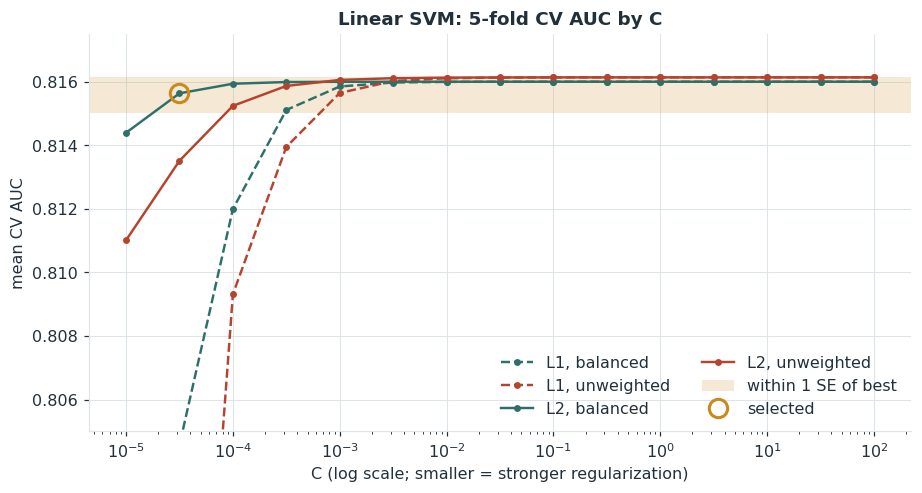

In [10]:
cv = pd.DataFrame(res)
cv["C"]            = cv["param_linearsvc__C"].astype(float)
cv["penalty"]      = cv["param_linearsvc__penalty"]
cv["class_weight"] = cv["param_linearsvc__class_weight"].fillna("none")
top = cv["mean_test_AUC"].idxmax()
tol = cv.loc[top, "std_test_AUC"] / np.sqrt(N_FOLDS)
sel = svm_search.best_index_

fig, ax = plt.subplots(figsize=(8.5, 4.6))
colors = {"none": PALETTE["pos"], "balanced": PALETTE["prot"]}
for (pen, cw), g in cv.groupby(["penalty", "class_weight"]):
    ax.plot(g["C"], g["mean_test_AUC"], color=colors[cw], ls="--" if pen == "l1" else "-",
            marker="o", ms=3.5, lw=1.6, label=f"{pen.upper()}, {'unweighted' if cw == 'none' else 'balanced'}")
ax.axhspan(cv.loc[top, "mean_test_AUC"] - tol, cv.loc[top, "mean_test_AUC"],
           color=PALETTE["accent"], alpha=.18, lw=0, label="within 1 SE of best")
ax.plot(cv.loc[sel, "C"], cv.loc[sel, "mean_test_AUC"], "o", ms=12, mfc="none",
        mec=PALETTE["accent"], mew=2, label="selected")
ax.set_xscale("log"); ax.set_ylim(0.805, 0.8175)
ax.set_xlabel("C (log scale; smaller = stronger regularization)"); ax.set_ylabel("mean CV AUC")
ax.set_title("Linear SVM: 5-fold CV AUC by C"); ax.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

**Why the curve is flat.** AUC depends only on how the model ranks people. For a linear
model the ranking comes from the *direction* of the weight vector; scaling the weights
changes nothing. With about 177,000 training rows and only 22 features, the data pins that
direction down tightly. Once `C` is above about 0.01 the penalty is negligible, and every
setting, L1 or L2, converges to the same model. Class weighting mostly shifts the
intercept, which does not affect ranking. Tuning only matters at heavy regularization,
where the penalty starts to shrink or drop real signal.

For the same reason the linear SVM and logistic regression end up with nearly the same
AUC (§6): both find nearly the same direction in the same 22 features. Better scores would
have to come from the features, such as interactions or new variables, not from hyperparameters.

Top 10 settings by mean CV AUC, plus the selected one.

In [11]:
show = cv.sort_values("mean_test_AUC", ascending=False).head(10).index.union([sel])
cv_table = pd.DataFrame({
    "C":            cv["C"],
    "penalty":      cv["penalty"],
    "class_weight": cv["class_weight"],
    "CV AUC":       cv["mean_test_AUC"],
    "AUC sd":       cv["std_test_AUC"],
    "CV AP":        cv["mean_test_AP"],
    "fit s":        cv["mean_fit_time"],
    "selected":     np.where(cv.index == sel, "✓", ""),
}).loc[show].sort_values("CV AUC", ascending=False)
display(cv_table.style.format({"C": "{:.2e}", "CV AUC": "{:.4f}", "AUC sd": "{:.4f}",
                               "CV AP": "{:.4f}", "fit s": "{:.2f}"}).hide(axis="index"))

C,penalty,class_weight,CV AUC,AUC sd,CV AP,fit s,selected
3.16e+00,l1,none,0.8161,0.0025,0.4365,0.36,
1.00e+01,l1,none,0.8161,0.0025,0.4365,0.34,
1.00e+02,l1,none,0.8161,0.0025,0.4365,0.33,
3.16e+01,l1,none,0.8161,0.0025,0.4365,0.37,
1.00e+02,l2,none,0.8161,0.0025,0.4365,0.32,
3.16e+01,l2,none,0.8161,0.0025,0.4365,0.36,
1.00e+01,l2,none,0.8161,0.0025,0.4365,0.33,
3.16e+00,l2,none,0.8161,0.0025,0.4365,0.36,
1.00e+00,l2,none,0.8161,0.0025,0.4365,0.30,
1.00e+00,l1,none,0.8161,0.0025,0.4365,0.33,


## 5. Threshold Tuning

Each model's threshold is picked on the validation set. The plots show precision,
recall, and F2 at each threshold, and the threshold with the highest F2 is marked.
Logistic regression is on the left and the linear SVM is on the right.

Logistic regression outputs a probability. The SVM outputs a signed distance from its
boundary, so its thresholds are on that scale. Its plot covers the central 99% of
validation scores.

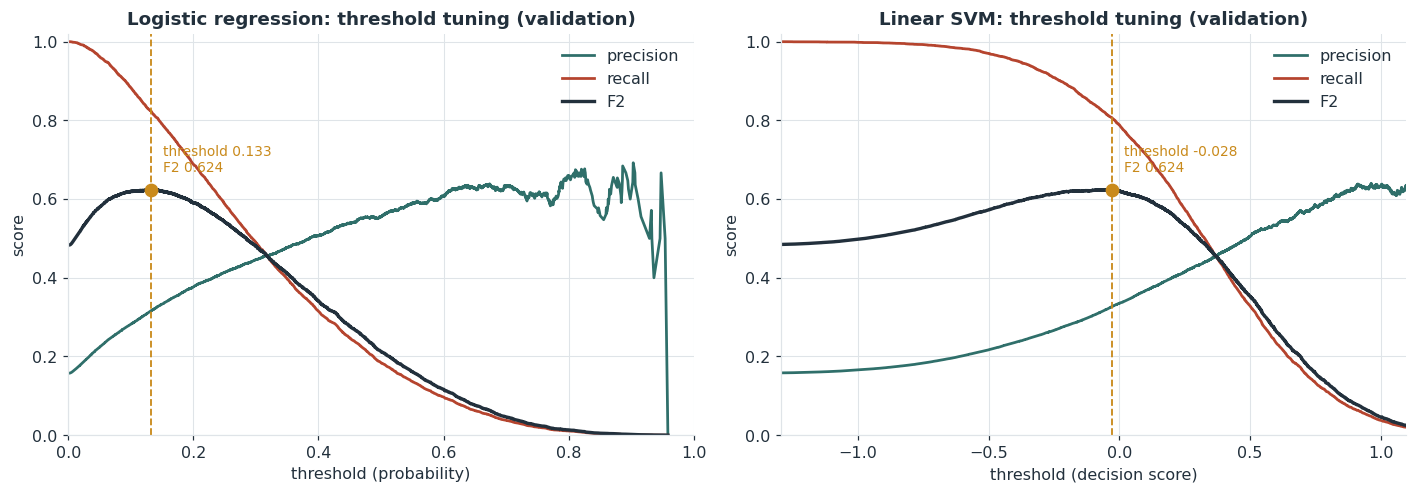

Logistic regression  threshold +0.133: precision 0.317, recall 0.823, F2 0.624
Linear SVM           threshold -0.028: precision 0.327, recall 0.807, F2 0.624


In [12]:
def f2_curve(y_true, s):
    """Precision, recall, and F2 at every threshold."""
    prec, rec, thr = precision_recall_curve(y_true, s)
    prec, rec = prec[:-1], rec[:-1]
    f2 = np.where(prec + rec > 0, 5 * prec * rec / (4 * prec + rec), 0)
    return thr, prec, rec, f2


def tune(ax, name, s_val, xlim=(0, 1), xlabel="threshold"):
    """Plot precision, recall, and F2 by threshold; return the max-F2 operating point."""
    thr, prec, rec, f2 = f2_curve(y_val, s_val)
    i = int(np.argmax(f2))

    ax.plot(thr, prec, color=PALETTE["prot"], lw=1.8, label="precision")
    ax.plot(thr, rec,  color=PALETTE["pos"],  lw=1.8, label="recall")
    ax.plot(thr, f2,   color=PALETTE["ink"],  lw=2.2, label="F2")
    ax.axvline(thr[i], color=PALETTE["accent"], ls="--", lw=1.2)
    ax.plot(thr[i], f2[i], "o", color=PALETTE["accent"], ms=8)
    ax.annotate(f"threshold {thr[i]:.3f}\nF2 {f2[i]:.3f}", (thr[i], f2[i]),
                xytext=(8, 12), textcoords="offset points", color=PALETTE["accent"], fontsize=9)
    ax.set_xlim(*xlim); ax.set_ylim(0, 1.02)
    ax.set_xlabel(xlabel); ax.set_ylabel("score")
    ax.set_title(f"{name}: threshold tuning (validation)"); ax.legend(loc="upper right")
    return dict(threshold=thr[i], val_precision=prec[i], val_recall=rec[i], val_f2=f2[i])


p_val_lr  = logit.predict(sm.add_constant(X_val))
s_val_svm = svm.decision_function(X_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
TUNED = {
    "Logistic regression": tune(axes[0], "Logistic regression", p_val_lr,
                                xlabel="threshold (probability)"),
    "Linear SVM":          tune(axes[1], "Linear SVM", s_val_svm,
                                xlim=np.percentile(s_val_svm, [0.5, 99.5]),
                                xlabel="threshold (decision score)"),
}
plt.tight_layout(); plt.show()

for name, t in TUNED.items():
    print(f"{name:<20} threshold {t['threshold']:+.3f}: precision {t['val_precision']:.3f}, "
          f"recall {t['val_recall']:.3f}, F2 {t['val_f2']:.3f}")

## 6. Results

ROC curves for both models on the test set.

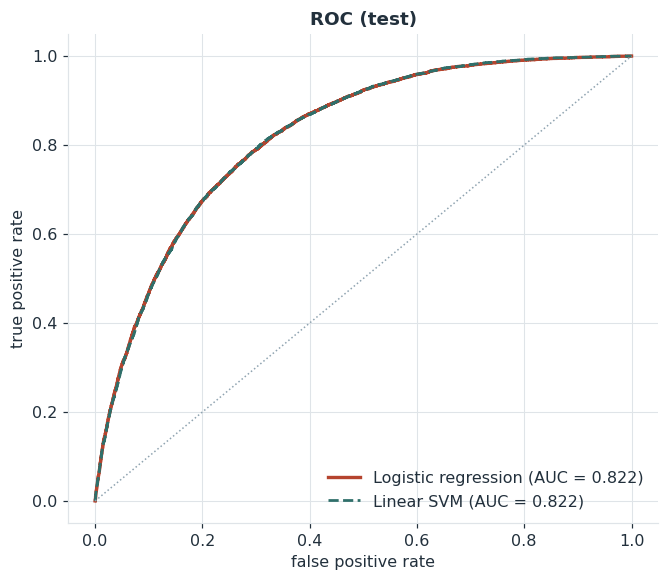

In [13]:
p_test_lr  = logit.predict(sm.add_constant(X_test))
s_test_svm = svm.decision_function(X_test)

RESULTS = {
    "Logistic regression": dict(**TUNED["Logistic regression"], s_test=p_test_lr),
    "Linear SVM":          dict(**TUNED["Linear SVM"],          s_test=s_test_svm),
}
STYLE = {"Logistic regression": dict(color=PALETTE["pos"],  lw=2.2),
         "Linear SVM":          dict(color=PALETTE["prot"], lw=1.8, ls="--")}

fig, ax = plt.subplots(figsize=(6.2, 5.4))
for name, r in RESULTS.items():
    fpr, tpr, _ = roc_curve(y_test, r["s_test"])
    ax.plot(fpr, tpr, **STYLE[name], label=f"{name} (AUC = {roc_auc_score(y_test, r['s_test']):.3f})")
ax.plot([0, 1], [0, 1], color=PALETTE["neg"], ls=":", lw=1)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC (test)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

Each model is scored at its tuned threshold on the validation set (where the
threshold was picked) and on the test set. Models are ranked by test F2.

In [14]:
rows = []
for name, r in RESULTS.items():
    pred = r["s_test"] >= r["threshold"]
    rows.append({
        ("", "Model"):               name,
        ("Validation", "Precision"): r["val_precision"],
        ("Validation", "Recall"):    r["val_recall"],
        ("Validation", "F2"):        r["val_f2"],
        ("Test", "Precision"):       precision_score(y_test, pred),
        ("Test", "Recall"):          recall_score(y_test, pred),
        ("Test", "F2"):              fbeta_score(y_test, pred, beta=2),
    })
results = pd.DataFrame(rows)
results.columns = pd.MultiIndex.from_tuples(results.columns)
results = results.sort_values(("Test", "F2"), ascending=False).reset_index(drop=True)
results.insert(0, ("", "Rank"), range(1, len(results) + 1))
display(results.style.format("{:.4f}", subset=results.columns[2:]).hide(axis="index"))

Confusion matrix for the best model on the test set.

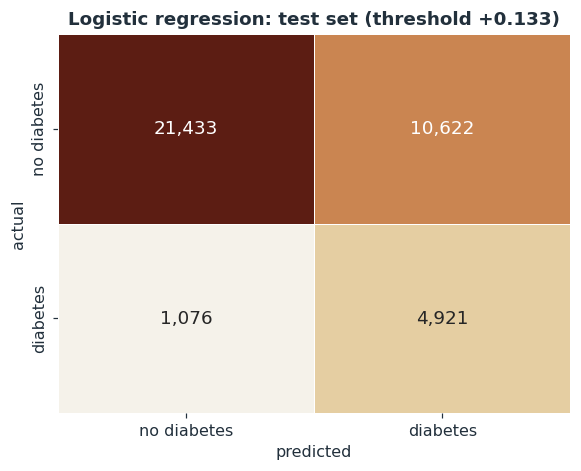

recall    : 0.821  (4,921 of 5,997 cases flagged)
precision : 0.317  (4,921 of 15,543 flags are cases)


In [15]:
best = results.iloc[0][("", "Model")]
r = RESULTS[best]
cm = confusion_matrix(y_test, r["s_test"] >= r["threshold"])

fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ, cbar=False, ax=ax,
            linewidths=.6, linecolor="white", annot_kws={"fontsize": 12},
            xticklabels=["no diabetes", "diabetes"], yticklabels=["no diabetes", "diabetes"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title(f"{best}: test set (threshold {r['threshold']:+.3f})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"recall    : {tp/(tp+fn):.3f}  ({tp:,} of {tp+fn:,} cases flagged)")
print(f"precision : {tp/(tp+fp):.3f}  ({tp:,} of {tp+fp:,} flags are cases)")